In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset into DataFrame
df = pd.read_csv('road_accident_dataset.csv')
# Check data types, memory usage, and non-null counts
print(df.info())
# Preview first 5 rows to see actual data format
display(df.head())
# Count missing values per column to identify data quality issues
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,220.414651,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856982,22072.878502,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,42.374452,9856.915064,Wet,Speeding,4,29164.412982,58009.145124,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212566,20907.151302,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293921,13584.060759,South America,3883.645634


Country                        0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Urban/Rural                    0
Road Type                      0
Weather Conditions             0
Visibility Level               0
Number of Vehicles Involved    0
Speed Limit                    0
Driver Age Group               0
Driver Gender                  0
Driver Alcohol Level           0
Driver Fatigue                 0
Vehicle Condition              0
Pedestrians Involved           0
Cyclists Involved              0
Accident Severity              0
Number of Injuries             0
Number of Fatalities           0
Emergency Response Time        0
Traffic Volume                 0
Road Condition                 0
Accident Cause                 0
Insurance Claims               0
Medical Cost                   0
Economic Loss                  0
Region                         0
Population Density             0
dtype: int

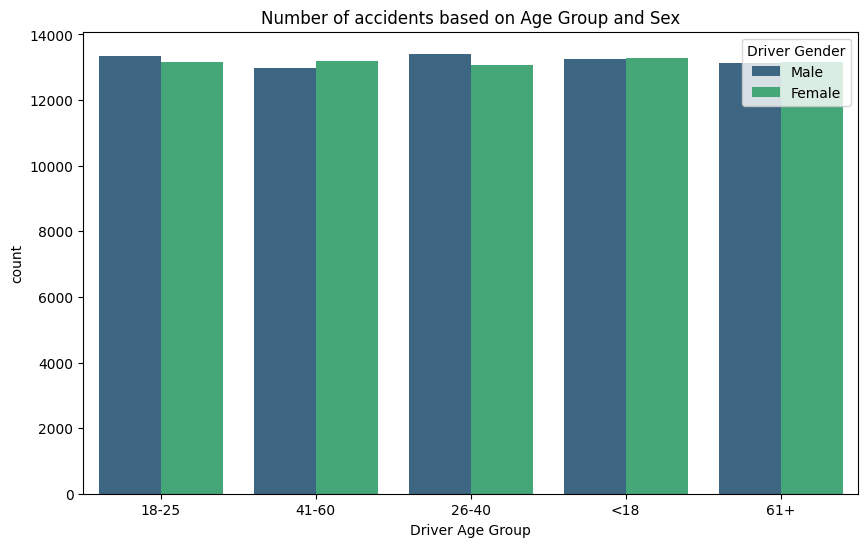

In [3]:
# Set figure size
plt.figure(figsize=(10,6))
# Create grouped bar chart: accident counts by age group, colored by gender
sns.countplot(data=df, x='Driver Age Group', hue='Driver Gender', palette='viridis')
# Add chart title
plt.title('Number of accidents based on Age Group and Sex')
# Render the plot
plt.show()

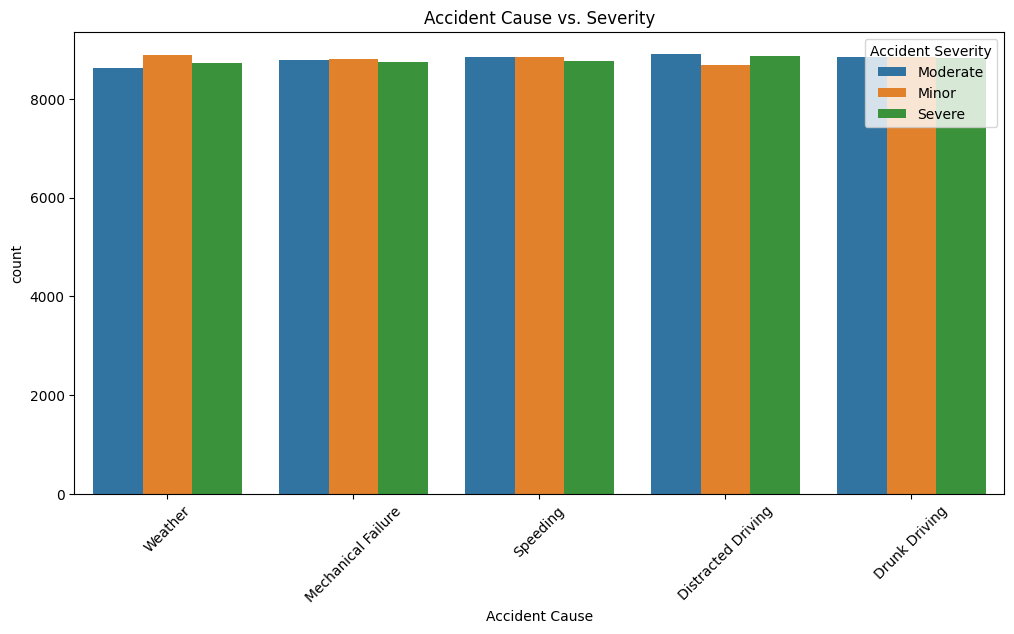

In [ ]:
# Set figure size
plt.figure(figsize=(12,6))
# Create grouped bar chart: accident counts by cause, colored by severity
sns.countplot(data=df, x='Accident Cause', hue='Accident Severity')
# Add chart title
plt.title('Accident Cause vs. Severity')
# Rotate x-axis labels 45 degrees for better readability
plt.xticks(rotation=45)
#Render the plot
plt.show()

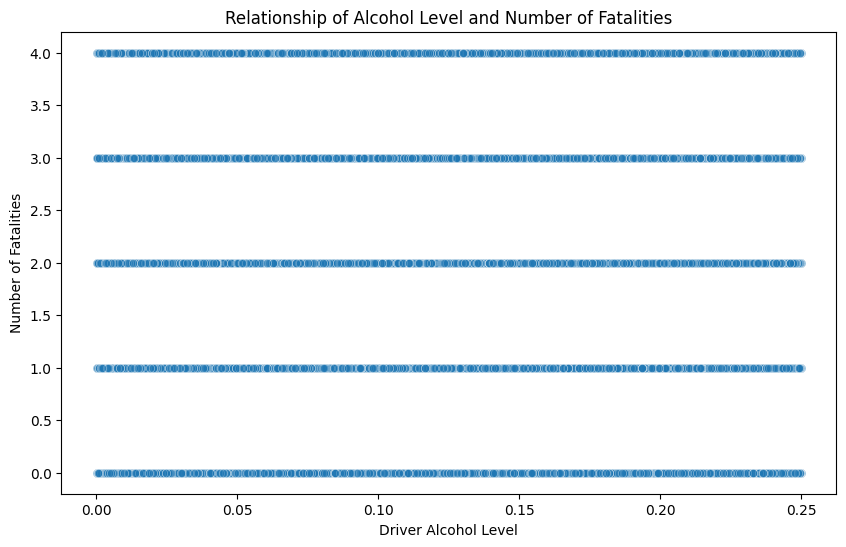

In [ ]:
# Set figure size
plt.figure(figsize=(10,6))
# Create scatter plot showing relationship between driver alcohol level and fatalities
# alpha = 0.5 makes points semi-transparent to show overlapping data
sns.scatterplot(data=df, x='Driver Alcohol Level', y='Number of Fatalities', alpha=0.5)
# Add chart title
plt.title('Relationship of Alcohol Level and Number of Fatalities')
#Render the plot
plt.show()

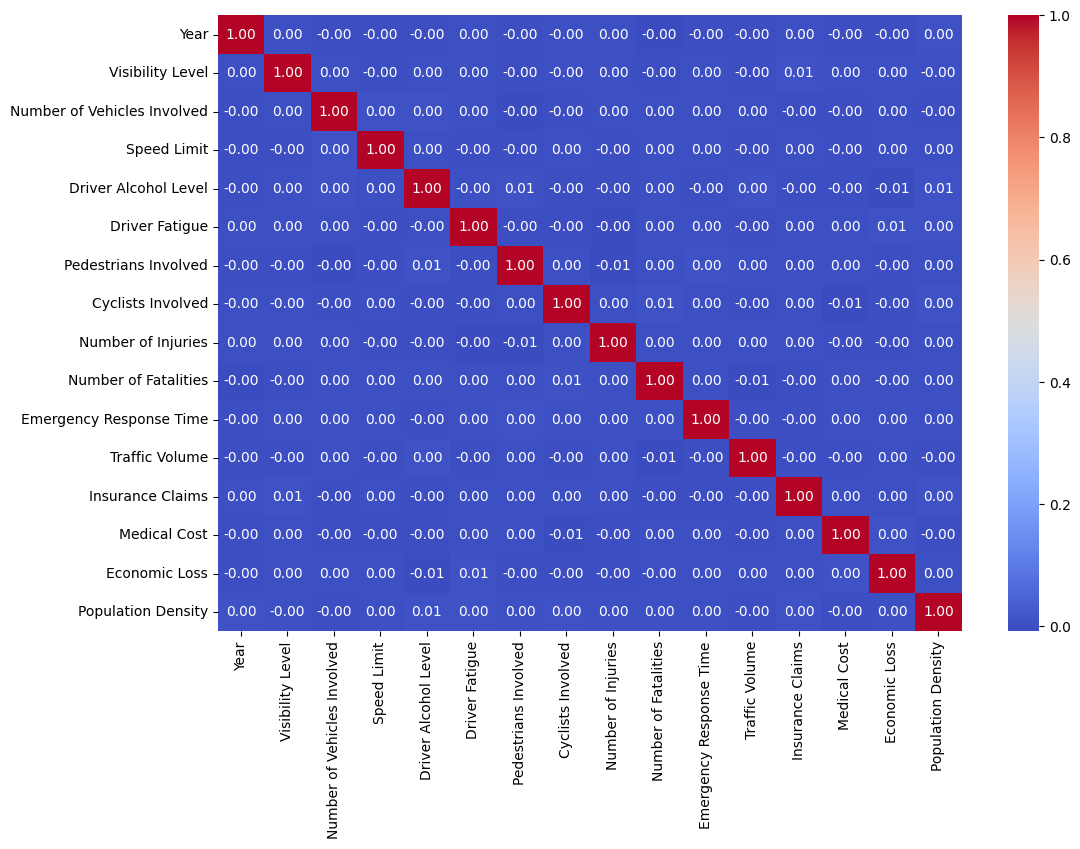

In [ ]:
# Set figure size
plt.figure(figsize=(12,8))
# Select only numeric columns from DataFrame for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number])
# Create heatmap showing correlations between numeric variables
# annot=True displays correlation values, cmap='coolwarm' sets color scheme, fmt='.2f' formats to 2 decimals
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
# Render the plot
plt.show()

In [ ]:
# Group data by Region, sum Economic Loss for each region, and sort from highest to lowest
economic_impact = df.groupby('Region')['Economic Loss'].sum().sort_values(ascending=False)
# Print the economic loss totals by region
print(economic_impact)

Region
Australia        1.341756e+09
Asia             1.334716e+09
South America    1.328847e+09
Europe           1.326871e+09
North America    1.325561e+09
Name: Economic Loss, dtype: float64


In [ ]:
# Get list of all column names that contain numeric data types
numerical_cols = df.select_dtypes(include=[np.number]).columns
# Print header for the statistics section
print("Basic Statistics for Numerical Columns:")
# Calculate and display summary statistics for all numeric columns
# round(2) = rounds all values to 2 decimal places
print(df[numerical_cols].describe().round(2))

Basic Statistics for Numerical Columns:
            Year  Visibility Level  Number of Vehicles Involved  Speed Limit  \
count  132000.00         132000.00                    132000.00    132000.00   
mean     2011.97            275.04                         2.50        74.54   
std         7.20            129.92                         1.12        26.00   
min      2000.00             50.00                         1.00        30.00   
25%      2006.00            162.34                         2.00        52.00   
50%      2012.00            274.67                         3.00        74.00   
75%      2018.00            388.01                         3.00        97.00   
max      2024.00            500.00                         4.00       119.00   

       Driver Alcohol Level  Driver Fatigue  Pedestrians Involved  \
count             132000.00        132000.0             132000.00   
mean                   0.13             0.5                  1.00   
std                    0.07     

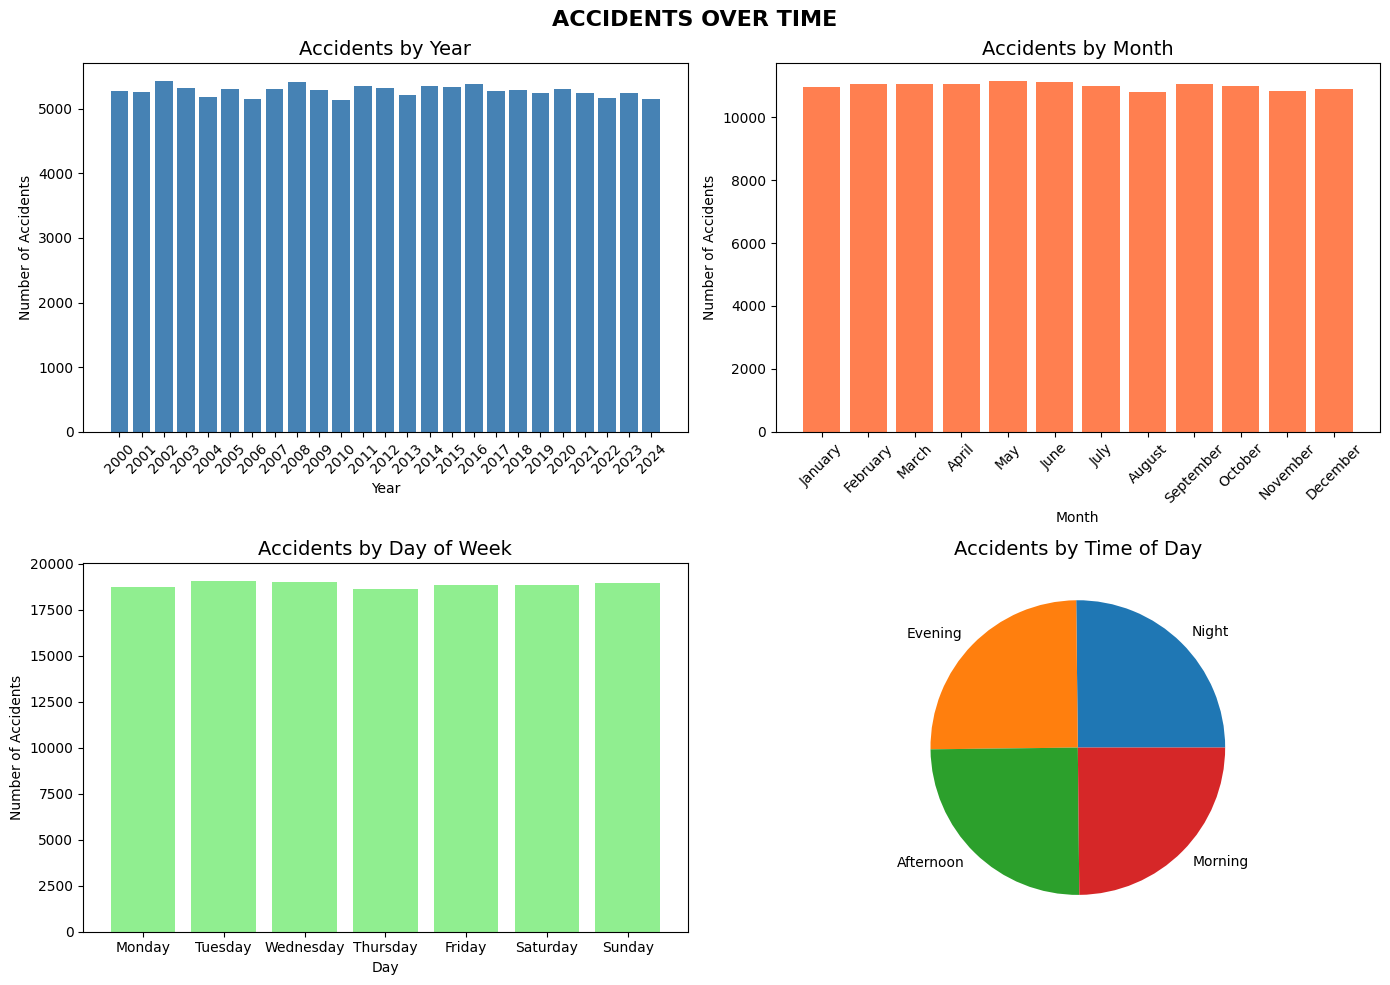

In [ ]:
# Create a 2x2 grid of subplots with specified figure size
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Add main title to the entire figure
fig.suptitle('ACCIDENTS OVER TIME', fontsize=16, fontweight='bold')
# Top-left plot: Bar chart of accidents by year
year_counts = df['Year'].value_counts().sort_index()
axes[0,0].bar(year_counts.index.astype(str), year_counts.values, color='steelblue')
axes[0,0].set_title('Accidents by Year', fontsize=14)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Accidents')
axes[0,0].tick_params(axis='x', rotation=45)
# Top-right plot: Bar chart of accidents by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['Month'].value_counts().reindex(month_order)# Reorder months chronologically
axes[0,1].bar(month_counts.index, month_counts.values, color='coral')
axes[0,1].set_title('Accidents by Month', fontsize=14)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Number of Accidents')
axes[0,1].tick_params(axis='x', rotation=45)
# Bottom-left plot: Bar chart of accidents by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Day of Week'].value_counts().reindex(day_order)# Reorder days chronologically
axes[1,0].bar(day_counts.index, day_counts.values, color='lightgreen')
axes[1,0].set_title('Accidents by Day of Week', fontsize=14)
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Number of Accidents')
# Bottom-right plot: Pie chart of accidents by time of day
time_counts = df['Time of Day'].value_counts() # Count accidents per time period
axes[1,1].pie(time_counts.values, labels=time_counts.index)
axes[1,1].set_title('Accidents by Time of Day', fontsize=14)
# Automatically adjust spacing between subplots to prevent overlap
plt.tight_layout()
# Render
plt.show()


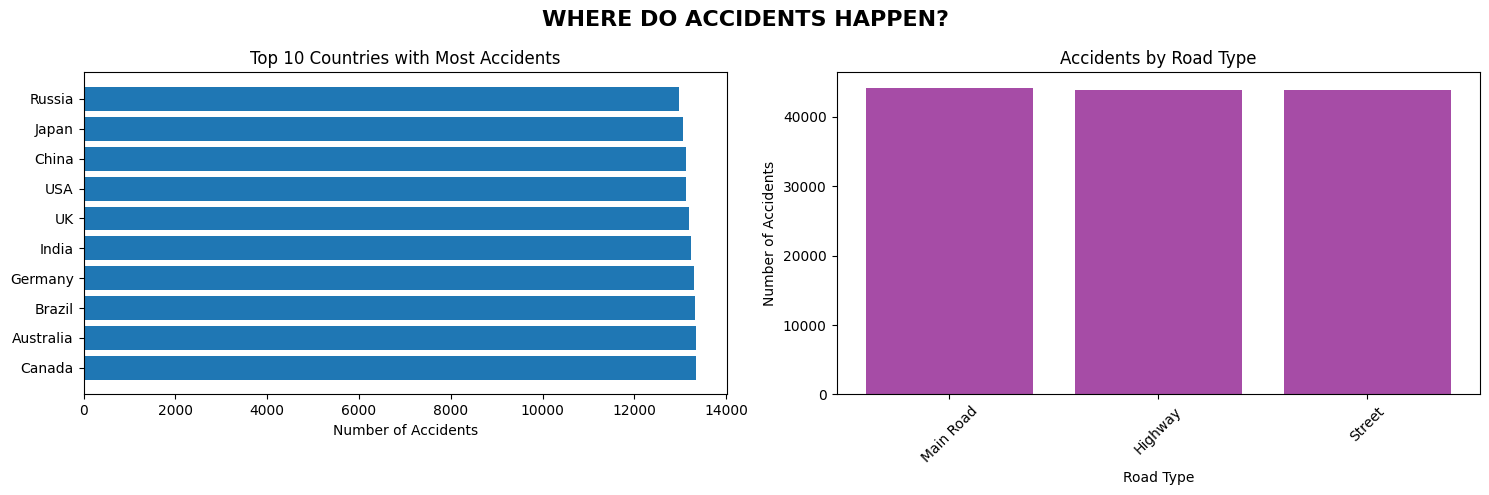

In [ ]:
# Create a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Add main title
fig.suptitle('WHERE DO ACCIDENTS HAPPEN?', fontsize=16, fontweight='bold')

# Left plot: Horizontal bar chart of top 10 countries
country_counts = df['Country'].value_counts().head(10) # Count accidents per country, keep top 10
axes[0].barh(country_counts.index, country_counts.values) # Horizontal bars for country names readability
axes[0].set_title('Top 10 Countries with Most Accidents', fontsize=12)
axes[0].set_xlabel('Number of Accidents')
# Right plot: Vertical bar chart of accidents by road type
road_counts = df['Road Type'].value_counts() # Count accidents per road type
axes[1].bar(road_counts.index, road_counts.values, color='purple', alpha=0.7)
axes[1].set_title('Accidents by Road Type', fontsize=12)
axes[1].set_xlabel('Road Type')
axes[1].set_ylabel('Number of Accidents')
axes[1].tick_params(axis='x', rotation=45)
# Automatically adjust spacing between plots
plt.tight_layout()
# Render
plt.show()

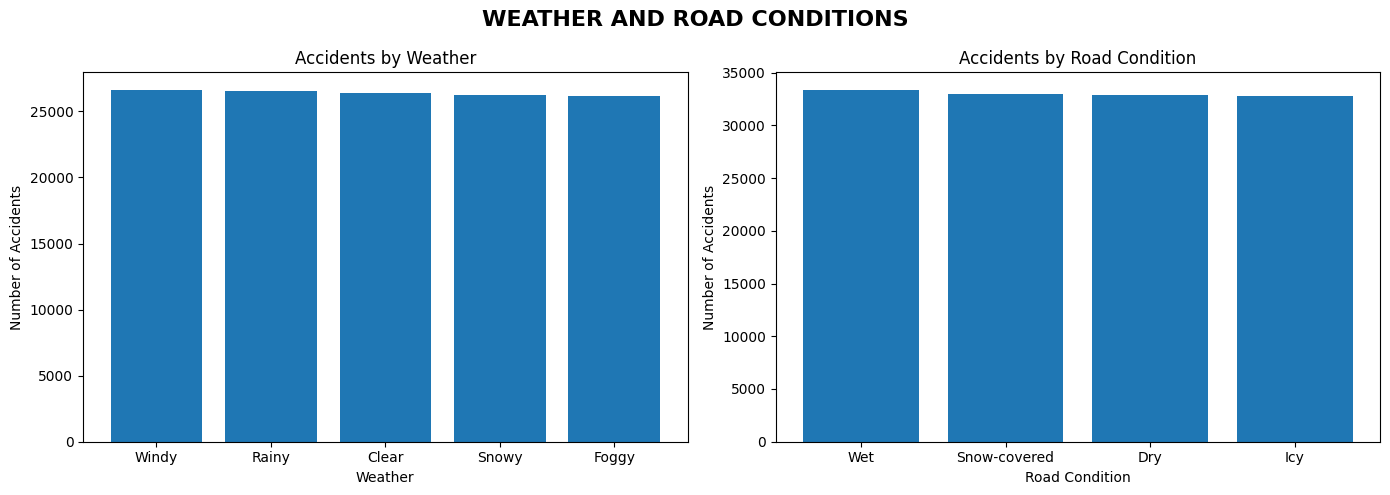

In [ ]:
# Create a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Add main title
fig.suptitle('WEATHER AND ROAD CONDITIONS', fontsize=16, fontweight='bold')
# Left plot: Bar chart of accidents by weather conditions
weather_counts = df['Weather Conditions'].value_counts()# Count accidents per weather type
axes[0].bar(weather_counts.index, weather_counts.values)
axes[0].set_title('Accidents by Weather', fontsize=12)
axes[0].set_xlabel('Weather')
axes[0].set_ylabel('Number of Accidents')
# Right plot: Bar chart of accidents by road condition
road_cond_counts = df['Road Condition'].value_counts() # Count accidents per road condition type
axes[1].bar(road_cond_counts.index, road_cond_counts.values)
axes[1].set_title('Accidents by Road Condition', fontsize=12)
axes[1].set_xlabel('Road Condition')
axes[1].set_ylabel('Number of Accidents')
# Automatically adjust spacing between plots
plt.tight_layout()
# Render
plt.show()